# Explore here

In [64]:
import requests
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [98]:


url = "https://api.worldbank.org/v2/country"
# url = "https://api.worldbank.org/v2/indicator"

params = {
    'format': "json",
    "per_page": 50,
    "page": 1,
    "date": "2010:2024"
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()
payload = response.json()

print("Metadata:",payload[0])
print("First item:", payload[1][0])


Metadata: {'page': 1, 'pages': 6, 'per_page': '50', 'total': 295}
First item: {'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


In [ ]:
#SP.POP.TOTL
#NY.GDP.PCAP.CD
#EN.ATM.CO2E.PC
#SP.DYN.LE00.IN
#1.0HCount.1.90usd

params = {
    'format': "json",
    "per_page": 200,
    "page": 1,
    "date": "2010:2024"
}

#url = "https://api.worldbank.org/v2/country/BRA;PER;MAR;KOR;PHL/indicator/SP.POP.TOTL?date=2010:2024"
#url = "https://api.worldbank.org/v2/country/BRA;PER;MAR;KOR;PHL/indicator/SP.DYN.LE00.IN"
#url = "https://api.worldbank.org/v2/country/BRA;PER;MAR;KOR;PHL/indicator/SP.POP.TOTL;SP.DYN.LE00.IN?source=2"
#url = "https://api.worldbank.org/v2/country/BRA;PER;MAR;KOR;PHL/indicator/SP.POP.TOTL;SP.DYN.LE00.IN?source=2"
#url_test = "https://api.worldbank.org/v2/country/chn;ago/indicator/SI.POV.DDAY;SP.POP.TOTL?source=2"
response = requests.get(url, params=params, timeout=30)
response.raise_for_status()
payload = response.json()

print("Metadata:",payload[0])
print("First item:", payload[1][0])
print(len(payload))
print(len(payload[1]))

Metadata: {'page': 1, 'pages': 1, 'per_page': 200, 'total': 75, 'sourceid': '2', 'lastupdated': '2026-07-01'}
First item: {'indicator': {'id': 'SP.DYN.LE00.IN', 'value': 'Life expectancy at birth, total (years)'}, 'country': {'id': 'BR', 'value': 'Brazil'}, 'countryiso3code': 'BRA', 'date': '2024', 'value': 76.023, 'unit': '', 'obs_status': '', 'decimal': 0}
2
75


In [115]:
SO3_codes = ["CHL","MAR","KOR","PHL","PER"]
ind_codes = ["SP.POP.TOTL", "SP.DYN.LE00.IN"]


#bad
#url_temp = "https://api.worldbank.org/v2/country/CHL;PER;MAR;KOR;PHL/indicator/SP.DYN.LE00.IN;SP.POP.TOTL"

#good
url_temp = "https://api.worldbank.org/v2/country/BRA;PER;MAR;KOR;PHL/indicator/SP.POP.TOTL;SP.DYN.LE00.IN?source=2"
response = requests.get(url_temp, params=params, timeout=30)
response.raise_for_status()
payload = response.json()
print("MetaData",payload[0])
#print("First item:", payload[1][0])
print(len(payload[1]))

data = []
for year_val in payload[1]:
    #print(year_val)
    #'countryiso3code', 'date', 'value'ArithmeticError
    data.append({'ISO3':year_val['countryiso3code'], 'Population':year_val['value'], 'Year':year_val['date']})
print(data[0])



MetaData {'page': 1, 'pages': 2, 'per_page': 100, 'total': 150, 'sourceid': None, 'lastupdated': '2026-07-01'}
100
{'ISO3': 'BRA', 'Population': 211998573, 'Year': '2024'}


In [84]:
#check for nulls
df = pd.DataFrame(data)
print(df.isnull().sum())

#check types
print(df.dtypes)

#need to convert year to int
df['Year'] = df['Year'].astype(int)


ISO3          0
Population    0
Year          0
dtype: int64
ISO3            str
Population    int64
Year            str
dtype: object


In [85]:
print(df.dtypes)
df.head(10)

ISO3            str
Population    int64
Year          int64
dtype: object


,ISO3,Population,Year
0,CHL,19764771,2024
1,CHL,19658835,2023
2,CHL,19553036,2022
3,CHL,19456334,2021
4,CHL,19370624,2020
5,CHL,19197744,2019
6,CHL,18893191,2018
7,CHL,18558868,2017
8,CHL,18267221,2016
9,CHL,18047625,2015


   ISO3  Population  Year
45  PER    34217848  2024
46  PER    33845617  2023
47  PER    33475438  2022
48  PER    33155882  2021
49  PER    32838579  2020


<Axes: xlabel='Year', ylabel='Population'>

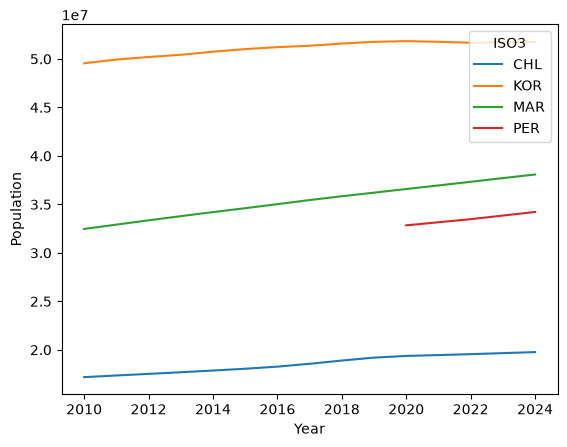

In [ ]:
#Analysis and Visualization

#by country
df_chl = df[df['ISO3'] == 'CHL']
df_per = df[df['ISO3'] == 'PER']
df_mar = df[df['ISO3'] == 'MAR']
df_kor = df[df['ISO3'] == 'KOR']
df_phl = df[df['ISO3'] == 'PHL']

print(df_per.head(10))

#plot population over time for all 5 countries selected
sns.lineplot(data=df, x='Year',y="Population",hue='ISO3')